## Задание
Продолжаем работать с объединенным датасетом merged_data

**Задача 1** 

Цель: выделить пользователей, которые делают упор на индивидуальные тренировки.

Что сделать:
Выберите пользователей, у которых >70% тренировок — индивидуальные.
Для этих пользователей:
+ Посчитайте средний чек;
+ Посчитайте среднее число тренировок в месяц;
+ Разбейте их по городам и полу.

Вопросы для анализа:

+ Кто чаще выбирает индивидуальные тренировки?
+ Есть ли зависимость от пола или города?
+ Насколько высок средний чек у таких пользователей?

**Задача 2.**
Найдите 10 пользователей с наибольшим общим количеством посещений (групповые + индивидуальные тренировки) за весь период наблюдения.

Что нужно сделать:

+ Рассчитайте общее количество тренировок для каждого пользователя.

+ Определите 10 самых активных пользователей и сохраните их идентификаторы в виде списка.

Постройте распределение этих пользователей по:

+ городу
+ полу

Вопросы для анализа:
+ В каких городах больше всего супер-активных клиентов?
+ Какого они пола?

**Задача 3** 
Ваша цель — проанализировать, как менялась клиентская база по месяцам:
сколько клиентов приходило, сколько уходило и сколько оставалось активными.

Шаги:
+ Новые клиенты — это те, у кого первый месяц появления (минимальный mon в данных).

+ Ушедшие клиенты — это те, у кого последний месяц активности (максимальный mon в данных).

+ Активные клиенты — это те, кто был активен в конкретном месяце.

Что нужно сделать:
Рассчитайте три метрики для каждого месяца:
+ new_clients: количество клиентов, для которых этот месяц — первый.
+ gone_clients: количество клиентов, для которых этот месяц — последний.
+ active_clients: общее количество уникальных клиентов в этом месяце.

Для этого:
Создайте три отдельных датафрейма:

+ с новыми клиентами по месяцам,
+ с ушедшими клиентами по месяцам,
+ с активными клиентами по месяцам.

Объедините их по полю mon.

Постройте линейный график с тремя линиями.

Подсказка:
+ Используйте groupby и nunique() для подсчёта количества клиентов.
+ Для объединения датафреймов — merge.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# загружаем очищенный датасет
df = pd.read_csv('merged_data.csv')
df.head(3)

,id_user,mon,cnt_group,cnt_indiv,sum_group,sum_indiv,cnt_total,sum_total,min_mon,max_mon,city,age,gender
0,1000,2023-03,0,2,0,3600,2,3600,2023-03,2023-12,СПб,44.0,female
1,1000,2023-04,0,4,0,7200,4,7200,2023-03,2023-12,СПб,44.0,female
2,1000,2023-05,0,4,0,6400,4,6400,2023-03,2023-12,СПб,44.0,female


### Задача 1. Пользователи с 70%+ инд.тренировок

In [15]:
user_cnt_indiv = df.groupby(['id_user','city','gender']).agg({'mon':'count',
                                               'cnt_indiv':'sum',
                                               'cnt_total':'sum',
                                                'sum_total':'sum'}).reset_index().rename(columns = {'mon':'nmonths'})
user_cnt_indiv

,id_user,city,gender,nmonths,cnt_indiv,cnt_total,sum_total
0,1000,СПб,female,9,33,33,58600
1,1001,Москва,female,11,23,129,124800
2,1002,Москва,male,11,64,128,166000
3,1004,Екатеринбург,male,9,18,18,32000
4,1005,СПб,female,2,7,7,12600
...,...,...,...,...,...,...,...
833,1992,СПб,male,4,12,39,43200
834,1993,СПб,male,2,2,24,22000
835,1994,Казань,male,1,0,7,5600
836,1995,Москва,female,2,0,23,18400


In [16]:
user_cnt_indiv['avg_check_per_mon'] = user_cnt_indiv['sum_total'] / user_cnt_indiv['nmonths']
user_cnt_indiv['avg_train_per_mon'] = user_cnt_indiv['cnt_total'] / user_cnt_indiv['nmonths']
user_cnt_indiv['share_indiv'] = user_cnt_indiv['cnt_indiv'] / user_cnt_indiv['cnt_total']
user_cnt_indiv

,id_user,city,gender,nmonths,cnt_indiv,cnt_total,sum_total,avg_check_per_mon,avg_train_per_mon,share_indiv
0,1000,СПб,female,9,33,33,58600,6511.111111,3.666667,1.000000
1,1001,Москва,female,11,23,129,124800,11345.454545,11.727273,0.178295
2,1002,Москва,male,11,64,128,166000,15090.909091,11.636364,0.500000
3,1004,Екатеринбург,male,9,18,18,32000,3555.555556,2.000000,1.000000
4,1005,СПб,female,2,7,7,12600,6300.000000,3.500000,1.000000
...,...,...,...,...,...,...,...,...,...,...
833,1992,СПб,male,4,12,39,43200,10800.000000,9.750000,0.307692
834,1993,СПб,male,2,2,24,22000,11000.000000,12.000000,0.083333
835,1994,Казань,male,1,0,7,5600,5600.000000,7.000000,0.000000
836,1995,Москва,female,2,0,23,18400,9200.000000,11.500000,0.000000


In [17]:
df_indiv = user_cnt_indiv[user_cnt_indiv['share_indiv'] > 0.7].reset_index(drop=True)
df_indiv

,id_user,city,gender,nmonths,cnt_indiv,cnt_total,sum_total,avg_check_per_mon,avg_train_per_mon,share_indiv
0,1000,СПб,female,9,33,33,58600,6511.111111,3.666667,1.0
1,1004,Екатеринбург,male,9,18,18,32000,3555.555556,2.000000,1.0
2,1005,СПб,female,2,7,7,12600,6300.000000,3.500000,1.0
3,1007,Москва,female,4,5,5,9000,2250.000000,1.250000,1.0
4,1009,Москва,female,4,9,9,16200,4050.000000,2.250000,1.0
...,...,...,...,...,...,...,...,...,...,...
276,1982,Москва,female,7,22,22,39000,5571.428571,3.142857,1.0
277,1983,СПб,female,1,6,6,10800,10800.000000,6.000000,1.0
278,1985,Екатеринбург,female,3,10,10,18000,6000.000000,3.333333,1.0
279,1988,Екатеринбург,female,5,18,18,32400,6480.000000,3.600000,1.0


In [18]:
user_ind70 = df_indiv.groupby(['city', 'gender']).agg(ctn_users = ('id_user', 'nunique'),
                                                      avg_check = ('avg_check_per_mon', 'mean'),
                                                      avg_train = ('avg_train_per_mon', 'mean')).reset_index()

user_ind70.head(10)

,city,gender,ctn_users,avg_check,avg_train
0,Екатеринбург,female,12,5391.746032,3.009524
1,Екатеринбург,male,12,5832.394180,3.256184
2,Казань,female,8,6297.500000,3.756250
3,Казань,male,12,5229.378307,2.931548
4,Москва,female,118,5565.425624,3.141311
5,Москва,male,59,6915.316115,3.872733
6,СПб,female,32,6093.278770,3.399777
7,СПб,male,28,5024.889456,2.821443


In [21]:
print('Кто чаще выбирает индивидуальные тренировки? - женщины')
print('Есть ли зависимость от пола или города? - да , в Москве больше всего занимаются индивидуальными треннировками')
print('Насколько высок средний чек у таких пользователей? - в среднемо около 6к')

Кто чаще выбирает индивидуальные тренировки? - женщины
Есть ли зависимость от пола или города? - да , в Москве больше всего занимаются индивидуальными треннировками
Насколько высок средний чек у таких пользователей? - в среднемо около 6к


### Задача 2. Топ-10 клиентов

In [30]:
df_tren = df.groupby(['id_user','city','gender']).agg({'cnt_total':'sum'}).reset_index()
sorted_df_tren = df_tren.sort_values(by='cnt_total', ascending=False)
top_10 = sorted_df_tren.head(10)
top_10

,id_user,city,gender,cnt_total
319,1381,Москва,female,159
12,1013,Москва,male,151
551,1657,СПб,male,144
420,1506,Москва,female,138
780,1929,Москва,male,130
474,1570,Екатеринбург,male,129
1,1001,Москва,female,129
2,1002,Москва,male,128
168,1194,СПб,female,127
485,1582,Екатеринбург,male,127


In [34]:
top_10_list = top_10['id_user'].tolist()
print(top_10_list)

[1381, 1013, 1657, 1506, 1929, 1570, 1001, 1002, 1194, 1582]


In [35]:
city_distribution = top_10['city'].value_counts()
print(city_distribution)

city
Москва          6
СПб             2
Екатеринбург    2
Name: count, dtype: int64


In [36]:
gender_distribution = top_10['gender'].value_counts()
print(gender_distribution)

gender
male      6
female    4
Name: count, dtype: int64


In [37]:
print('В каких городах больше всего супер-активных клиентов? - Москва , СПб , Екатеренбург')
print('Какого они пола? - мужчины и женщины')

В каких городах больше всего супер-активных клиентов? - Москва , СПб , Екатеренбург
Какого они пола? - мужчины и женщины


### Задача 3. Динамика клиентской базы

In [43]:
new_clients=df.groupby(['min_mon']).agg({'id_user':'nunique'}).reset_index().rename(columns={'min_mon':'mon','id_user':'new_clients'})
gone_clients =df.groupby(['max_mon']).agg({'id_user':'nunique'}).reset_index().rename(columns={'max_mon':'mon','id_user':'gone_clients'})
active_clients=df.groupby (['mon']).agg({'id_user':'nunique'}).reset_index().rename(columns={'id_user':'active_clients'})
united_df=active_clients.merge(new_clients,on='mon').merge(gone_clients,on='mon')
united_df

,mon,active_clients,new_clients,gone_clients
0,2023-01,337,337,15
1,2023-02,350,88,22
2,2023-03,355,83,37
3,2023-04,345,62,21
4,2023-05,360,57,21
5,2023-06,383,51,13
6,2023-07,412,48,33
7,2023-08,423,35,33
8,2023-09,429,28,55
9,2023-10,441,27,101


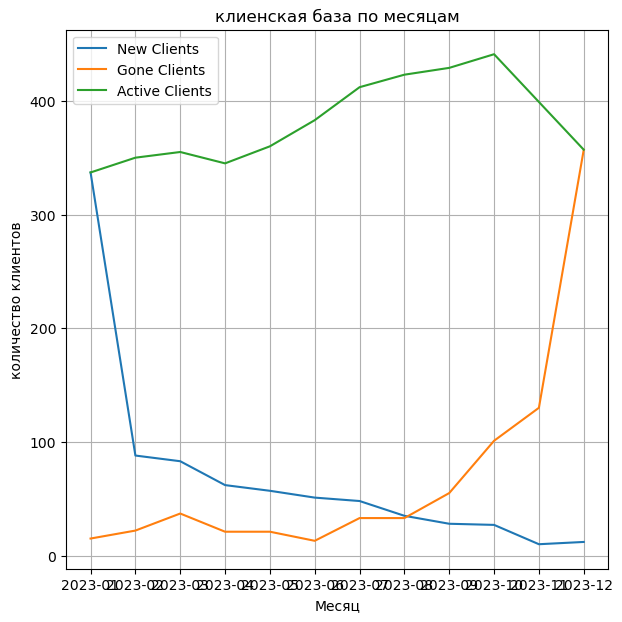

In [45]:
plt.figure(figsize=(7,7))
plt.plot(united_df['mon'],united_df['new_clients'],label='New Clients')
plt.plot(united_df['mon'],united_df['gone_clients'],label='Gone Clients')
plt.plot(united_df['mon'],united_df['active_clients'],label='Active Clients')
plt.title('клиенская база по месяцам')
plt.xlabel('Месяц')
plt.ylabel('количество клиентов')
plt.grid(True)
plt.legend()
plt.show()